# 05 - Dataset Loader

This notebook builds a clean dataset loader for the MVTec AD bottle dataset.

The goal is to convert the folder structure into a table that the model code can use.

## What The Loader Should Return

For every image, we want:

- image path
- split: `train` or `test`
- label: `good`, `broken_large`, `broken_small`, `contamination`
- binary target: good or defective
- mask path if available
- image size

This metadata becomes the base for baseline detection, Anomalib training, classification, and evaluation.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Bottle dataset:", BOTTLE_DIR)
print("Exists:", BOTTLE_DIR.exists())

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Bottle dataset: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\raw\mvtec_anomaly_detection\bottle
Exists: True


## Validate Dataset Folders

Before loading, confirm that the important folders exist.

In [2]:
required_paths = [
    BOTTLE_DIR / "train" / "good",
    BOTTLE_DIR / "test" / "good",
    BOTTLE_DIR / "test" / "broken_large",
    BOTTLE_DIR / "test" / "broken_small",
    BOTTLE_DIR / "test" / "contamination",
    BOTTLE_DIR / "ground_truth" / "broken_large",
    BOTTLE_DIR / "ground_truth" / "broken_small",
    BOTTLE_DIR / "ground_truth" / "contamination",
]

for path in required_paths:
    print(path.relative_to(PROJECT_ROOT), "->", "OK" if path.exists() else "MISSING")

data\raw\mvtec_anomaly_detection\bottle\train\good -> OK
data\raw\mvtec_anomaly_detection\bottle\test\good -> OK
data\raw\mvtec_anomaly_detection\bottle\test\broken_large -> OK
data\raw\mvtec_anomaly_detection\bottle\test\broken_small -> OK
data\raw\mvtec_anomaly_detection\bottle\test\contamination -> OK
data\raw\mvtec_anomaly_detection\bottle\ground_truth\broken_large -> OK
data\raw\mvtec_anomaly_detection\bottle\ground_truth\broken_small -> OK
data\raw\mvtec_anomaly_detection\bottle\ground_truth\contamination -> OK


## Loader Functions

These functions collect image records and connect defective test images with their ground truth masks.

In [3]:
DEFECT_LABELS = ["broken_large", "broken_small", "contamination"]
ALL_LABELS = ["good"] + DEFECT_LABELS


def read_image_shape(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        return None, None, None
    height, width = image.shape[:2]
    channels = 1 if image.ndim == 2 else image.shape[2]
    return width, height, channels


def get_mask_path(bottle_dir, image_path, label):
    if label == "good":
        return None

    mask_path = bottle_dir / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return mask_path if mask_path.exists() else None


def build_mvtec_bottle_records(bottle_dir):
    records = []

    train_good_dir = bottle_dir / "train" / "good"
    for image_path in sorted(train_good_dir.glob("*.png")):
        width, height, channels = read_image_shape(image_path)
        records.append({
            "split": "train",
            "label": "good",
            "target": 0,
            "target_name": "good",
            "is_defective": False,
            "image_path": str(image_path),
            "mask_path": None,
            "width": width,
            "height": height,
            "channels": channels,
        })

    test_dir = bottle_dir / "test"
    for label in ALL_LABELS:
        label_dir = test_dir / label
        for image_path in sorted(label_dir.glob("*.png")):
            width, height, channels = read_image_shape(image_path)
            mask_path = get_mask_path(bottle_dir, image_path, label)
            is_defective = label != "good"

            records.append({
                "split": "test",
                "label": label,
                "target": 1 if is_defective else 0,
                "target_name": "defective" if is_defective else "good",
                "is_defective": is_defective,
                "image_path": str(image_path),
                "mask_path": str(mask_path) if mask_path else None,
                "width": width,
                "height": height,
                "channels": channels,
            })

    return pd.DataFrame(records)

## Build Dataset Table

In [4]:
dataset_df = build_mvtec_bottle_records(BOTTLE_DIR)

print("Total records:", len(dataset_df))
dataset_df.head()

Total records: 292


,split,label,target,target_name,is_defective,image_path,mask_path,width,height,channels
0,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
1,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
2,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
3,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
4,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3


## Dataset Summary

Now check how many images are available per split and label.

In [5]:
summary_df = (
    dataset_df
    .groupby(["split", "label", "target_name"])
    .size()
    .reset_index(name="count")
)

summary_df

,split,label,target_name,count
0,test,broken_large,defective,20
1,test,broken_small,defective,22
2,test,contamination,defective,21
3,test,good,good,20
4,train,good,good,209


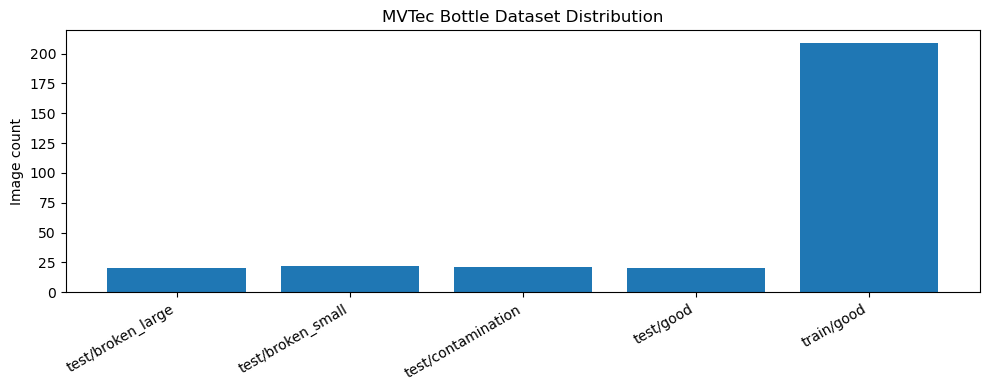

In [6]:
plt.figure(figsize=(10, 4))
plot_labels = summary_df["split"] + "/" + summary_df["label"]
plt.bar(plot_labels, summary_df["count"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Image count")
plt.title("MVTec Bottle Dataset Distribution")
plt.tight_layout()
plt.show()

## Check Image Sizes

This matters because models need consistent input dimensions. The preprocessing module will resize images later.

In [7]:
size_summary = (
    dataset_df
    .groupby(["width", "height", "channels"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

size_summary.head(10)

,width,height,channels,count
0,900,900,3,292


## Validate Masks

Every defective test image should have a matching ground truth mask. Good images should not have masks.

In [8]:
defective_df = dataset_df[dataset_df["is_defective"] == True]
missing_masks_df = defective_df[defective_df["mask_path"].isna()]

print("Defective images:", len(defective_df))
print("Missing masks:", len(missing_masks_df))

missing_masks_df.head()

Defective images: 63
Missing masks: 0


,split,label,target,target_name,is_defective,image_path,mask_path,width,height,channels


## View Samples From Each Label

Visual confirmation is important. Always inspect your data before training.

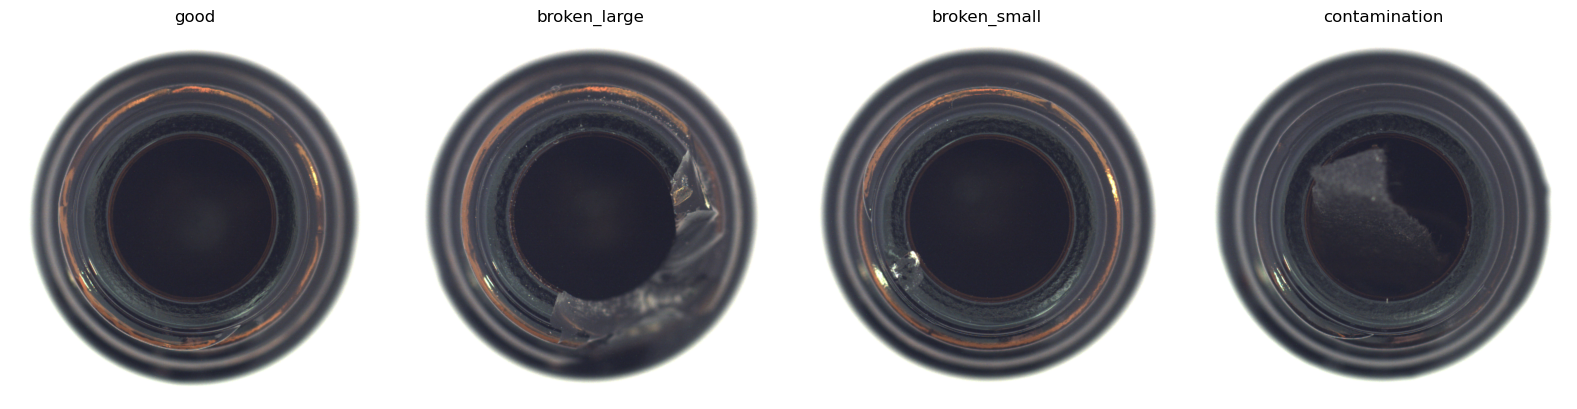

In [9]:
def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


samples = []
for label in ALL_LABELS:
    label_rows = dataset_df[(dataset_df["split"] == "test") & (dataset_df["label"] == label)]
    if label_rows.empty and label == "good":
        label_rows = dataset_df[(dataset_df["split"] == "train") & (dataset_df["label"] == label)]
    if not label_rows.empty:
        samples.append(label_rows.iloc[0])

fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
if len(samples) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, pd.DataFrame(samples).iterrows()):
    ax.imshow(read_rgb(row["image_path"]))
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## View Defect Masks

Masks show the defect area. Later, model heatmaps can be compared against these masks.

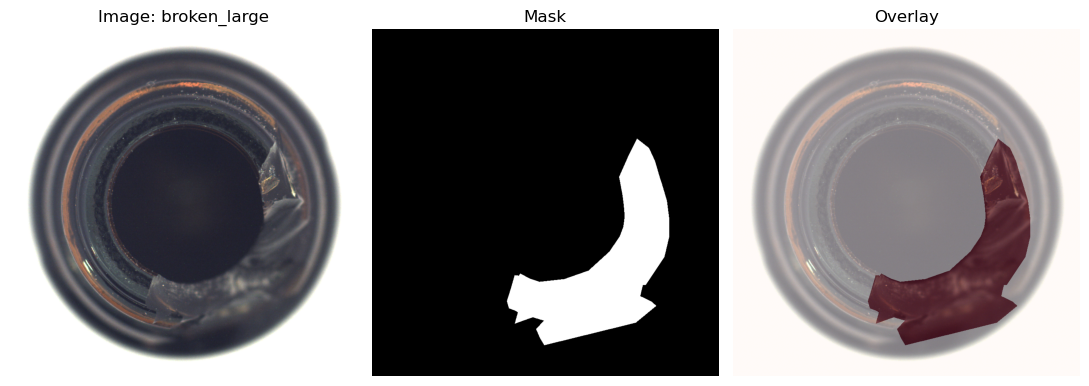

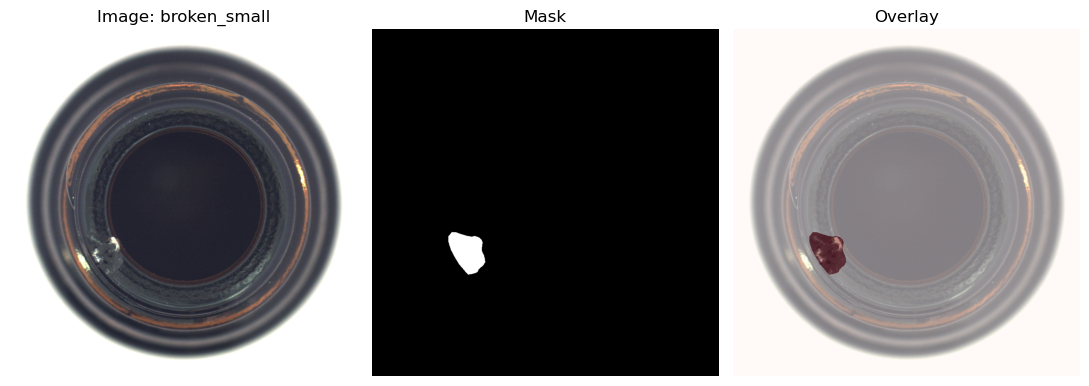

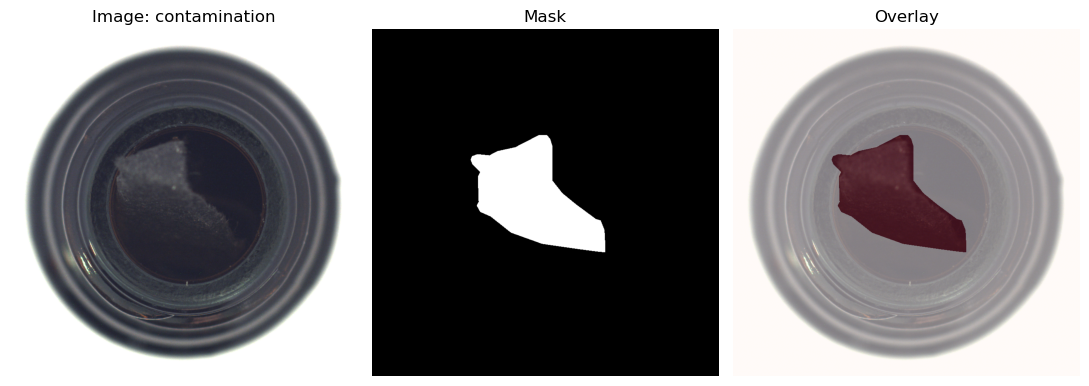

In [10]:
mask_samples = defective_df.dropna(subset=["mask_path"]).groupby("label").head(1)

for _, row in mask_samples.iterrows():
    image = read_rgb(row["image_path"])
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"Image: {row['label']}")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Mask")
    axes[2].imshow(image)
    axes[2].imshow(mask, cmap="Reds", alpha=0.45)
    axes[2].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Create Train/Test Tables

These separate tables are useful for training and evaluation.

In [11]:
train_df = dataset_df[dataset_df["split"] == "train"].reset_index(drop=True)
test_df = dataset_df[dataset_df["split"] == "test"].reset_index(drop=True)

print("Train records:", len(train_df))
print("Test records:", len(test_df))

display(train_df.head())
display(test_df.head())

Train records: 209
Test records: 83


,split,label,target,target_name,is_defective,image_path,mask_path,width,height,channels
0,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
1,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
2,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
3,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
4,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3


,split,label,target,target_name,is_defective,image_path,mask_path,width,height,channels
0,test,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
1,test,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
2,test,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
3,test,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
4,test,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3


## Save Dataset Metadata

Save CSV files so future notebooks and scripts can reuse the same dataset index.

In [12]:
dataset_csv = OUTPUT_DIR / "mvtec_bottle_dataset.csv"
train_csv = OUTPUT_DIR / "mvtec_bottle_train.csv"
test_csv = OUTPUT_DIR / "mvtec_bottle_test.csv"
summary_csv = OUTPUT_DIR / "mvtec_bottle_summary.csv"

dataset_df.to_csv(dataset_csv, index=False)
train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Saved:")
print(dataset_csv)
print(train_csv)
print(test_csv)
print(summary_csv)

Saved:
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\mvtec_bottle_dataset.csv
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\mvtec_bottle_train.csv
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\mvtec_bottle_test.csv
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\mvtec_bottle_summary.csv


## Loader Output Contract

The final loader output has these columns:

In [13]:
list(dataset_df.columns)

['split',
 'label',
 'target',
 'target_name',
 'is_defective',
 'image_path',
 'mask_path',
 'width',
 'height',
 'channels']

## Summary

You built the dataset loader foundation:

- loaded MVTec bottle image paths
- assigned labels
- assigned good/defective targets
- linked defect images to ground truth masks
- checked image sizes
- validated masks
- saved metadata CSV files

Next notebook: `06_baseline_defect_detection.ipynb`.